# Multivariate Analysis and Predictive Modeling of Digital Health Readiness in India

### DS3005 – Computational Algorithms in Data Science

**Team Members: Lakshya Gupta, Sarthak Goel, Krissh Modi**

In [4]:
"""
================================================================================
  Multivariate Analysis and Predictive Modeling of Digital Health Readiness
  in India — DS3005 Computational Algorithms in Data Science
  Authors : Lakshya Gupta, Sarthak Goel, Krissh Modi
  Date    : April 2026
================================================================================

Pipeline
────────
  STEP 1  │ Data Loading & Preprocessing
  STEP 2  │ Feature Engineering — Digital Readiness Score (DRS)
  STEP 3  │ Full-Predictor PCA
  STEP 4  │ K-Means Clustering
  STEP 5  │ Logistic Regression
  STEP 6  │ Random Forest
  STEP 7  │ Gradient Boosting
  STEP 8  │ Model Validation & Comparison
  STEP 9  │ Visualizations
================================================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 10})

SEED = 42
np.random.seed(SEED)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING & PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 1 — Data Loading & Preprocessing")
print("=" * 72)

# Dataset: Citizen Survey Dataset, India (Kalita et al., 2026)
# Source : https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/M1DFBO
DATA_PATH = "./dataverse_files/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025 (1)/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025.dta"
df = pd.read_stata(DATA_PATH)

# Note: Some variables are recoded from categorical to numeric for analysis
PREDICTOR_COLS = [
    "d1a", "d1b", "d1c", "d1d", "d1e", "d1f", "d1g", "d1h", "d1i", "d1j", "d1k", "d1l"
]
TARGET_COL = "any_insurance"  # Binary: "Have Insurance" (Y=1) vs "No" (Y=0)

print(f"  Dataset shape : {df.shape}")
print(f"  Available predictors (digital readiness indicators): {PREDICTOR_COLS}")
print(f"  Target variable: {TARGET_COL}")

# Convert target to binary (1 = Have Insurance, 0 = No)
df[TARGET_COL] = (df[TARGET_COL] == "Have Insurance").astype(int)
print(f"  Y=1 prevalence: {df[TARGET_COL].mean()*100:.1f}%")

# Select only rows with complete data for predictors and target
df_clean = df[PREDICTOR_COLS + [TARGET_COL]].dropna()
print(f"  Complete cases: {len(df_clean):,} / {len(df):,}")

# Convert categorical predictors to numeric (Agree=1, Disagree=0, other=NaN)
for col in PREDICTOR_COLS:
    df_clean[col] = (df_clean[col] == "Agree").astype(int)

df = df_clean.reset_index(drop=True)
print(f"  Dataset shape after cleaning: {df.shape}")
print(f"  Missing values: {df.isnull().sum().sum()}")

# Z-score standardisation — required before PCA and K-Means (scale-sensitive)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(df[PREDICTOR_COLS])
df_scaled = pd.DataFrame(X_scaled, columns=PREDICTOR_COLS, index=df.index)

print(f"  Predictors standardised: {df_scaled.shape}\n")

y = df[TARGET_COL].values
N = len(df)


STEP 1 — Data Loading & Preprocessing
  Dataset shape : (50217, 232)
  Available predictors (digital readiness indicators): ['d1a', 'd1b', 'd1c', 'd1d', 'd1e', 'd1f', 'd1g', 'd1h', 'd1i', 'd1j', 'd1k', 'd1l']
  Target variable: any_insurance
  Y=1 prevalence: 27.0%
  Complete cases: 50,000 / 50,217
  Dataset shape after cleaning: (50000, 13)
  Missing values: 0
  Predictors standardised: (50000, 12)



In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FEATURE ENGINEERING: Digital Readiness Score (DRS)
# ══════════════════════════════════════════════════════════════════════════════
# DRS is extracted as PC1 of a PCA over digital access indicators (d1a-d1f).
# These represent responses to questions about digital technology adoption.
#
# DRS_i = v₁ᵀ xᵢ  where v₁ is the eigenvector of the largest eigenvalue of Σ
#
# If PC1 explains < 60% of variance, a variance-weighted composite is used instead.

print("=" * 72)
print("STEP 2 — Feature Engineering: Digital Readiness Score (DRS)")
print("=" * 72)

DRS_COLS = ["d1a", "d1b", "d1c", "d1d", "d1e", "d1f"]
X_drs    = df_scaled[DRS_COLS].values

pca_drs      = PCA(n_components=len(DRS_COLS), random_state=SEED)
pca_drs.fit(X_drs)
pc1_variance = pca_drs.explained_variance_ratio_[0]

print(f"  Variance explained per PC: {np.round(pca_drs.explained_variance_ratio_ * 100, 1)} %")
print(f"  PC1 variance: {pc1_variance * 100:.1f}%")

if pc1_variance >= 0.60:
    DRS = pca_drs.transform(X_drs)[:, 0]
    print("  PC1 >= 60% — using PC1 as DRS")
else:
    weights = pca_drs.explained_variance_ratio_ / pca_drs.explained_variance_ratio_.sum()
    DRS = pca_drs.transform(X_drs) @ weights
    print("  PC1 < 60% — using variance-weighted composite as DRS")

print("\n  PC1 Loadings:")
for var, load in zip(DRS_COLS, pca_drs.components_[0]):
    print(f"    {var:<22} : {load:+.4f}")

df["DRS"]        = DRS
df_scaled["DRS"] = DRS
print(f"\n  DRS added. Mean = {DRS.mean():.3f}, Std = {DRS.std():.3f}\n")


STEP 2 — Feature Engineering: Digital Readiness Score (DRS)
  Variance explained per PC: [36.  16.8 13.6 12.2 11.3 10.2] %
  PC1 variance: 36.0%
  PC1 < 60% — using variance-weighted composite as DRS

  PC1 Loadings:
    d1a                    : +0.4258
    d1b                    : +0.4540
    d1c                    : +0.4638
    d1d                    : +0.3342
    d1e                    : +0.3504
    d1f                    : +0.4037

  DRS added. Mean = 0.000, Std = 0.590



In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — FULL-PREDICTOR PCA
# ══════════════════════════════════════════════════════════════════════════════
# Applied to all 9 predictors to reduce the feature space before clustering.
# Retains the top d components that together explain >= 80% cumulative variance.
# The projected matrix Z = X Vd serves as input to K-Means.

print("=" * 72)
print("STEP 3 — Full-Predictor PCA")
print("=" * 72)

X_full   = df_scaled[PREDICTOR_COLS].values
pca_full = PCA(n_components=None, random_state=SEED)
pca_full.fit(X_full)

cumvar          = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = int(np.argmax(cumvar >= 0.80)) + 1

print("  Cumulative variance by component:")
for i, (ev, cv) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar)):
    marker = "  <- 80% threshold" if i + 1 == n_components_80 else ""
    print(f"    PC{i+1}: {ev*100:5.1f}%  (cumulative {cv*100:5.1f}%){marker}")

pca_final = PCA(n_components=n_components_80, random_state=SEED)
Z = pca_final.fit_transform(X_full)

print(f"\n  Components retained: d = {n_components_80}")
print(f"  Projected matrix Z : {Z.shape}\n")

STEP 3 — Full-Predictor PCA
  Cumulative variance by component:
    PC1:  30.7%  (cumulative  30.7%)
    PC2:  11.9%  (cumulative  42.5%)
    PC3:   8.3%  (cumulative  50.9%)
    PC4:   7.7%  (cumulative  58.5%)
    PC5:   6.5%  (cumulative  65.0%)
    PC6:   6.2%  (cumulative  71.2%)
    PC7:   5.7%  (cumulative  76.9%)
    PC8:   5.4%  (cumulative  82.2%)  <- 80% threshold
    PC9:   5.1%  (cumulative  87.3%)
    PC10:   5.0%  (cumulative  92.3%)
    PC11:   4.5%  (cumulative  96.8%)
    PC12:   3.2%  (cumulative 100.0%)

  Components retained: d = 8
  Projected matrix Z : (50000, 8)



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
# Minimises WCSS = Σ_k Σ_{i∈Ck} ‖zᵢ − μₖ‖²
# Optimal K selected jointly by the elbow method and maximum silhouette score.
# Silhouette is computed on a 5,000-point subsample for efficiency.

print("=" * 72)
print("STEP 4 — K-Means Clustering")
print("=" * 72)

K_RANGE = range(2, 8)
wcss, sil_scores = [], []

sil_idx  = np.random.choice(N, min(5000, N), replace=False)
Z_sample = Z[sil_idx]

print("  Evaluating K values...", end="")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                max_iter=300, random_state=SEED)
    km.fit(Z)
    wcss.append(km.inertia_)
    labels_sample = km.labels_[sil_idx]
    sil = (silhouette_score(Z_sample, labels_sample, random_state=SEED)
           if len(np.unique(labels_sample)) > 1 else -1)
    sil_scores.append(sil)
    print(".", end="", flush=True)
print()

best_k_sil = K_RANGE.start + int(np.argmax(sil_scores))
print(f"\n  K   WCSS              Silhouette")
for k, w, s in zip(K_RANGE, wcss, sil_scores):
    marker = "  <- optimal" if k == best_k_sil else ""
    print(f"  K={k}  {w:>12,.0f}    {s:.4f}{marker}")

K_OPT          = best_k_sil
km_final       = KMeans(n_clusters=K_OPT, init="k-means++", n_init=20,
                        max_iter=500, random_state=SEED)
cluster_labels = km_final.fit_predict(Z)
df["cluster"]  = cluster_labels

print(f"\n  Optimal K = {K_OPT}")
for k, cnt in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f"  Cluster {k}: {cnt:,}  ({cnt/N*100:.1f}%)")

cluster_profile = (df[PREDICTOR_COLS + [TARGET_COL, "cluster"]]
                   .groupby("cluster").mean().round(3))
print(f"\n  Cluster Profiles:\n{cluster_profile}\n")

STEP 4 — K-Means Clustering
  Evaluating K values.........

  K   WCSS              Silhouette
  K=2       368,462    0.2637  <- optimal
  K=3       312,293    0.2346
  K=4       282,074    0.2178
  K=5       262,645    0.2256
  K=6       245,111    0.2183
  K=7       231,226    0.2255

  Optimal K = 2
  Cluster 0: 19,363  (38.7%)
  Cluster 1: 30,637  (61.3%)

  Cluster Profiles:
           d1a    d1b    d1c    d1d    d1e    d1f    d1g    d1h    d1i    d1j  \
cluster                                                                         
0        0.724  0.637  0.616  0.336  0.354  0.348  0.286  0.717  0.221  0.318   
1        0.952  0.921  0.909  0.731  0.738  0.872  0.784  0.979  0.805  0.854   

           d1k    d1l  any_insurance  
cluster                               
0        0.202  0.184          0.262  
1        0.728  0.712          0.277  



In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — LOGISTIC REGRESSION
# ══════════════════════════════════════════════════════════════════════════════
# P(Y=1 | X) = 1 / (1 + exp(−(β₀ + βᵀX)))
#
# Feature vector includes interaction terms derived from the digital readiness indicators:
#   These capture non-additive effects between different aspects of digital readiness.
#
# Cluster membership is added as dummy-encoded features (one dropped for identifiability).
# Coefficients are exponentiated to yield interpretable odds ratios e^βⱼ.

print("=" * 72)
print("STEP 5 — Logistic Regression")
print("=" * 72)

df_model = df_scaled.copy()

# Create interaction terms between digital readiness components
# Interaction between d1a (tech adoption) and d1f (digital skills)
df_model["d1a_x_d1f"] = df_scaled["d1a"] * df_scaled["d1f"]
# Interaction between d1c and d1d (access components)
df_model["d1c_x_d1d"] = df_scaled["d1c"] * df_scaled["d1d"]

cluster_dummies = pd.get_dummies(df["cluster"], prefix="cluster", drop_first=True)
df_model = pd.concat([df_model.reset_index(drop=True),
                      cluster_dummies.reset_index(drop=True)], axis=1)

FEATURE_COLS = (
    PREDICTOR_COLS
    + ["DRS", "d1a_x_d1f", "d1c_x_d1d"]
    + list(cluster_dummies.columns)
)

X = df_model[FEATURE_COLS].values
print(f"  Feature matrix: {X.shape}  (p = {X.shape[1]})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"  Y=1 — Train: {y_train.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%\n")

lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=500,
                        class_weight="balanced", random_state=SEED)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

odds_ratios = np.exp(lr.coef_[0])
print("  Odds Ratios (sorted by effect magnitude):")
for feat, OR in sorted(zip(FEATURE_COLS, odds_ratios), key=lambda x: -abs(x[1] - 1)):
    print(f"    {feat:<30}: {OR:.4f}  {'↑' if OR > 1 else '↓'}")
print()


STEP 5 — Logistic Regression
  Feature matrix: (50000, 16)  (p = 16)
  Train: 40,000  |  Test: 10,000
  Y=1 — Train: 27.2%  Test: 27.2%

  Odds Ratios (sorted by effect magnitude):
    d1l                           : 1.1345  ↑
    d1e                           : 0.8806  ↓
    cluster_1                     : 1.1090  ↑
    d1k                           : 1.0900  ↑
    d1f                           : 0.9249  ↓
    d1i                           : 0.9315  ↓
    d1a                           : 1.0563  ↑
    d1b                           : 0.9538  ↓
    d1d                           : 1.0377  ↑
    d1a_x_d1f                     : 1.0254  ↑
    d1g                           : 0.9769  ↓
    d1c_x_d1d                     : 0.9782  ↓
    d1c                           : 1.0214  ↑
    DRS                           : 0.9799  ↓
    d1h                           : 1.0188  ↑
    d1j                           : 0.9988  ↓



In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
# Ŷ = mode(T₁(X), …, T_B(X))
# B = 200 trees, each split considers m = √p random features.
# OOB score provides an unbiased generalisation estimate without a held-out set.

print("=" * 72)
print("STEP 6 — Random Forest")
print("=" * 72)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, max_features="sqrt",
    class_weight="balanced", oob_score=True,
    n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"  OOB accuracy: {rf.oob_score_:.4f}")

importance_df = (pd.DataFrame({"feature": FEATURE_COLS,
                                "importance": rf.feature_importances_})
                 .sort_values("importance", ascending=False))
print("\n  Top-10 Feature Importances:")
print(importance_df.head(10).to_string(index=False))
print()

STEP 6 — Random Forest
  OOB accuracy: 0.5298

  Top-10 Feature Importances:
  feature  importance
      DRS    0.167756
      d1l    0.129327
      d1k    0.107239
      d1e    0.083150
      d1i    0.056688
      d1h    0.056107
      d1g    0.055816
d1a_x_d1f    0.052899
      d1j    0.052649
d1c_x_d1d    0.052626



In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — GRADIENT BOOSTING
# ══════════════════════════════════════════════════════════════════════════════
# Third comparator (§5.7). Trees are built sequentially, each correcting the
# residuals of the prior ensemble. subsample=0.8 adds stochasticity to reduce
# variance (stochastic gradient boosting).

print("=" * 72)
print("STEP 7 — Gradient Boosting")
print("=" * 72)

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=SEED
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("  Gradient Boosting fitted.\n")

STEP 7 — Gradient Boosting
  Gradient Boosting fitted.



In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — MODEL VALIDATION & COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
# Three-layer evaluation strategy (§5.7):
#   Holdout metrics : Accuracy, Precision, Recall, F1, ROC-AUC on 20% test set
#   5-fold CV AUC   : on training set, stratified
#   Bootstrap CIs   : B=1000 resamples of the test set → 95% CI on ROC-AUC
#
# Primary metric is ROC-AUC (robust to class imbalance).

print("=" * 72)
print("STEP 8 — Model Validation & Comparison")
print("=" * 72)


def compute_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob), 4),
    }


def bootstrap_auc_ci(y_true, y_prob, B=1000, seed=SEED):
    """95% bootstrap confidence interval for ROC-AUC."""
    rng  = np.random.RandomState(seed)
    aucs = []
    for _ in range(B):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, [2.5, 97.5])


results_df = pd.DataFrame([
    compute_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"),
    compute_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"),
    compute_metrics(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting"),
]).set_index("Model")

print("\n  Holdout Test Set Metrics:")
print(results_df.to_string())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n  5-Fold CV ROC-AUC (training set):")
for model, name in [(lr, "Logistic Regression"),
                    (rf, "Random Forest"),
                    (gb, "Gradient Boosting")]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"    {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}"
          f"  (folds: {np.round(scores, 3)})")

print("\n  Bootstrap 95% CIs for ROC-AUC (B=1000):")
for y_prob, name in [(y_prob_lr, "Logistic Regression"),
                     (y_prob_rf, "Random Forest"),
                     (y_prob_gb, "Gradient Boosting")]:
    lo, hi = bootstrap_auc_ci(y_test, y_prob)
    auc    = roc_auc_score(y_test, y_prob)
    print(f"    {name:<25}: AUC = {auc:.4f}  [95% CI: {lo:.4f} – {hi:.4f}]")

print()

STEP 8 — Model Validation & Comparison

  Holdout Test Set Metrics:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.5113     0.3058  0.6296  0.4117   0.5738
Random Forest          0.5236     0.3116  0.6233  0.4155   0.5846
Gradient Boosting      0.7284     0.5000  0.0015  0.0029   0.5855

  5-Fold CV ROC-AUC (training set):
    Logistic Regression      : 0.5643 ± 0.0065  (folds: [0.551 0.568 0.567 0.566 0.569])
    Random Forest            : 0.5823 ± 0.0047  (folds: [0.575 0.584 0.586 0.58  0.588])
    Gradient Boosting        : 0.5835 ± 0.0046  (folds: [0.578 0.587 0.585 0.578 0.589])

  Bootstrap 95% CIs for ROC-AUC (B=1000):
    Logistic Regression      : AUC = 0.5738  [95% CI: 0.5621 – 0.5853]
    Random Forest            : AUC = 0.5846  [95% CI: 0.5726 – 0.5960]
    Gradient Boosting        : AUC = 0.5855  [95% CI: 0.5739 – 0.5972]



STEP 9 — Generating Visualizations


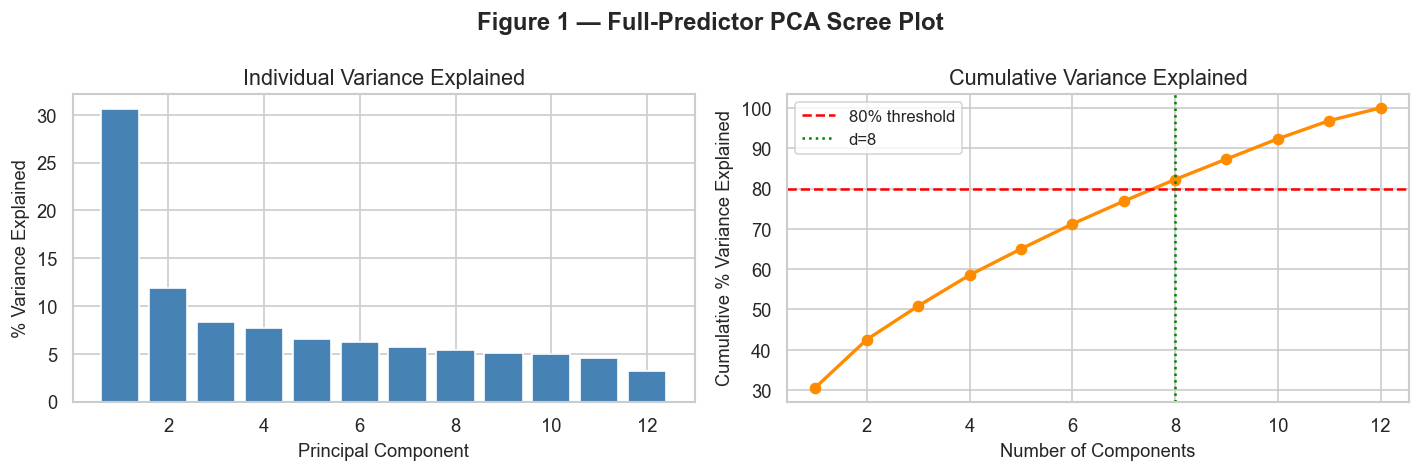

  ✓ Figure 1 displayed


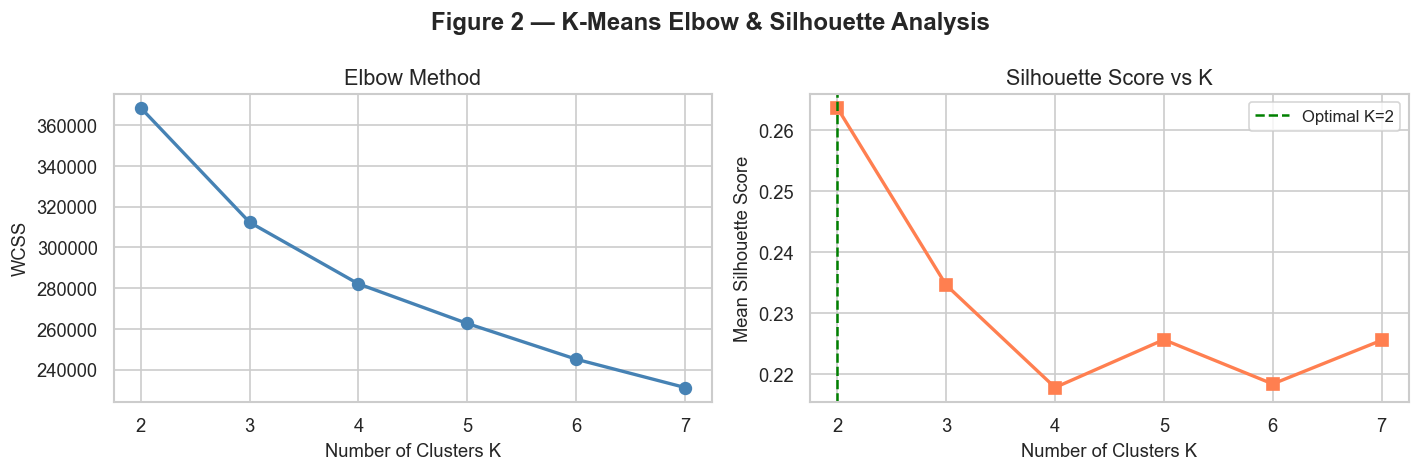

  ✓ Figure 2 displayed


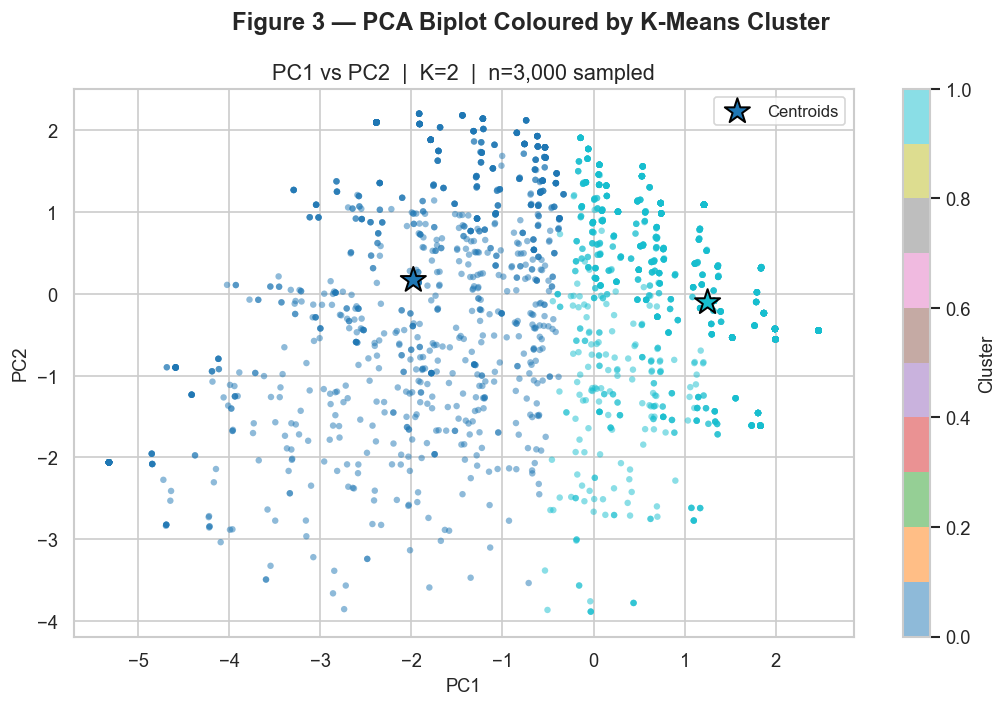

  ✓ Figure 3 displayed


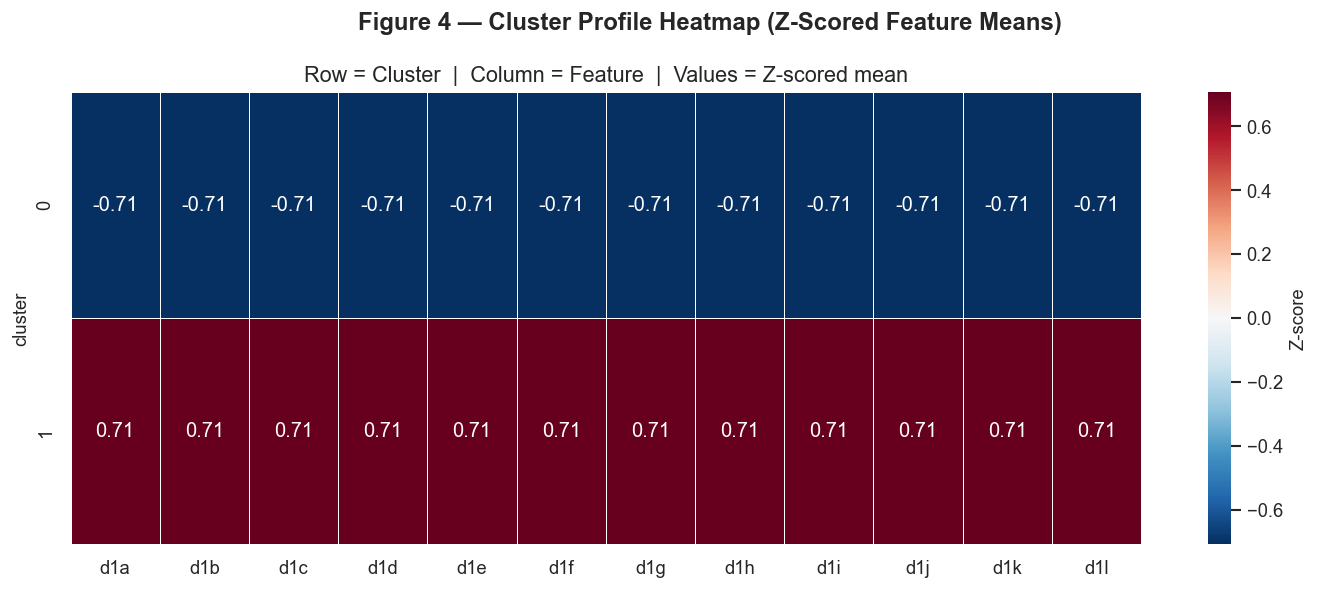

  ✓ Figure 4 displayed


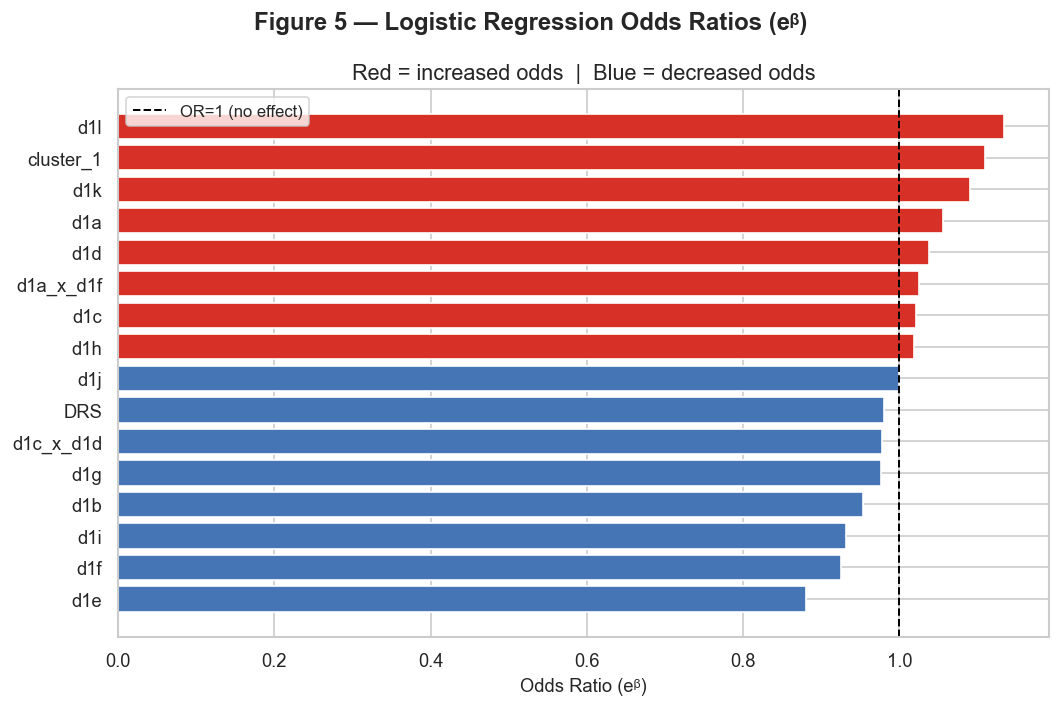

  ✓ Figure 5 displayed


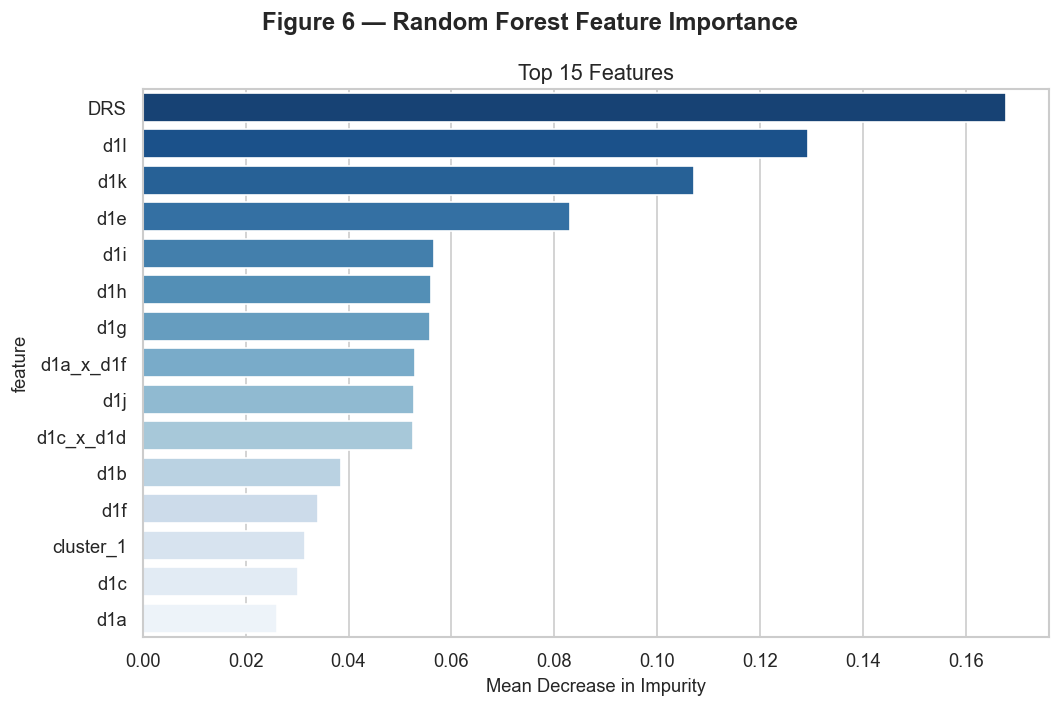

  ✓ Figure 6 displayed


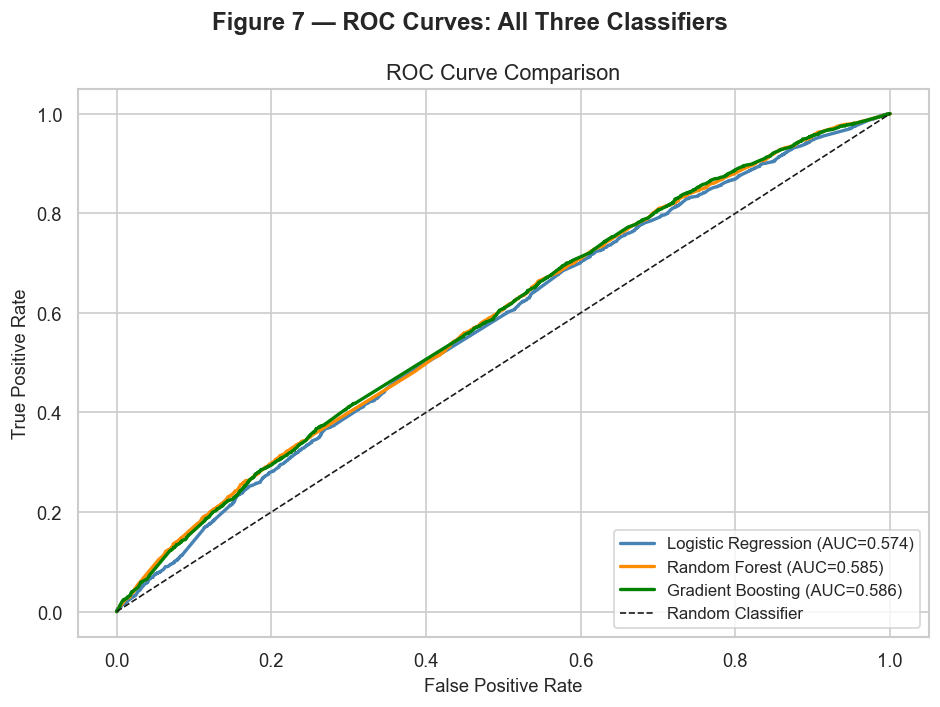

  ✓ Figure 7 displayed


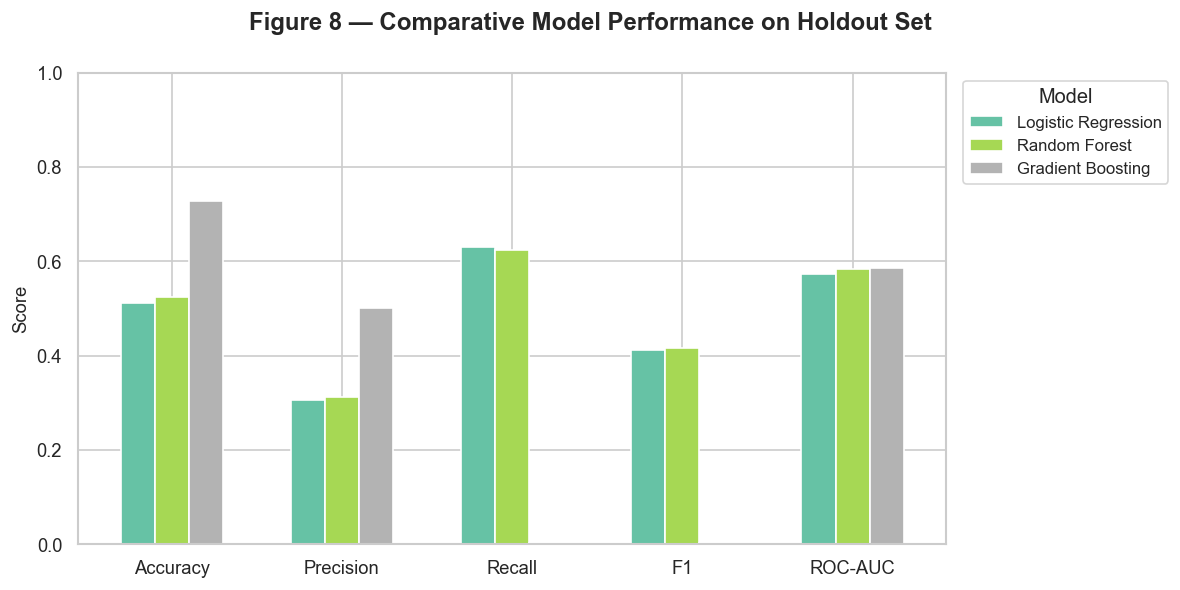

  ✓ Figure 8 displayed


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 9 — Generating Visualizations")
print("=" * 72)

# ── Figure 1: PCA Scree Plot ──────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("Figure 1 — Full-Predictor PCA Scree Plot", fontweight="bold")

comp_nums = range(1, pca_full.n_components_ + 1)
axes[0].bar(comp_nums, pca_full.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("% Variance Explained")
axes[0].set_title("Individual Variance Explained")

cumvar_pct = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(comp_nums, cumvar_pct, "o-", color="darkorange", linewidth=2)
axes[1].axhline(80, ls="--", color="red", label="80% threshold")
axes[1].axvline(n_components_80, ls=":", color="green", label=f"d={n_components_80}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative % Variance Explained")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 1 displayed")

# ── Figure 2: K-Means Elbow & Silhouette ─────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("Figure 2 — K-Means Elbow & Silhouette Analysis", fontweight="bold")

k_list = list(K_RANGE)
axes[0].plot(k_list, wcss, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(k_list, sil_scores, "s-", color="coral", linewidth=2, markersize=7)
axes[1].axvline(K_OPT, ls="--", color="green", label=f"Optimal K={K_OPT}")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 2 displayed")

# ── Figure 3: PCA Biplot Coloured by Cluster ─────────────────────────────────
fig3, ax = plt.subplots(figsize=(9, 6))
fig3.suptitle("Figure 3 — PCA Biplot Coloured by K-Means Cluster",
              fontweight="bold")

sample_idx = np.random.choice(N, min(3000, N), replace=False)
scatter = ax.scatter(
    Z[sample_idx, 0], Z[sample_idx, 1],
    c=cluster_labels[sample_idx], cmap="tab10",
    alpha=0.5, s=15, linewidths=0
)
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           c=range(K_OPT), cmap="tab10", marker="*",
           s=250, edgecolors="black", linewidths=1.2, label="Centroids", zorder=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PC1 vs PC2  |  K={K_OPT}  |  n={min(3000, N):,} sampled")
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 3 displayed")

# ── Figure 4: Cluster Profile Heatmap ────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(12, 5))
fig4.suptitle("Figure 4 — Cluster Profile Heatmap (Z-Scored Feature Means)",
              fontweight="bold")

profile_z = cluster_profile[PREDICTOR_COLS].apply(
    lambda col: (col - col.mean()) / col.std(), axis=0
)
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score"})
ax.set_title("Row = Cluster  |  Column = Feature  |  Values = Z-scored mean")
plt.tight_layout()
plt.show()
print("  ✓ Figure 4 displayed")

# ── Figure 5: Logistic Regression Odds Ratios ─────────────────────────────────
fig5, ax = plt.subplots(figsize=(9, 6))
fig5.suptitle("Figure 5 — Logistic Regression Odds Ratios (eᵝ)",
              fontweight="bold")

or_df  = (pd.DataFrame({"feature": FEATURE_COLS, "OR": odds_ratios})
          .sort_values("OR").reset_index(drop=True))
colors = ["#d73027" if o > 1 else "#4575b4" for o in or_df["OR"]]
ax.barh(or_df["feature"], or_df["OR"], color=colors, edgecolor="white")
ax.axvline(1.0, color="black", linewidth=1.2, linestyle="--", label="OR=1 (no effect)")
ax.set_xlabel("Odds Ratio (eᵝ)")
ax.set_title("Red = increased odds  |  Blue = decreased odds")
ax.legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 5 displayed")

# ── Figure 6: Random Forest Feature Importance ────────────────────────────────
fig6, ax = plt.subplots(figsize=(9, 6))
fig6.suptitle("Figure 6 — Random Forest Feature Importance", fontweight="bold")

sns.barplot(data=importance_df.head(15), x="importance", y="feature",
            palette="Blues_r", ax=ax)
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 15 Features")
plt.tight_layout()
plt.show()
print("  ✓ Figure 6 displayed")

# ── Figure 7: ROC Curves ──────────────────────────────────────────────────────
fig7, ax = plt.subplots(figsize=(8, 6))
fig7.suptitle("Figure 7 — ROC Curves: All Three Classifiers", fontweight="bold")

for y_prob, name, color in [
    (y_prob_lr, "Logistic Regression", "steelblue"),
    (y_prob_rf, "Random Forest",       "darkorange"),
    (y_prob_gb, "Gradient Boosting",   "green"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
print("  ✓ Figure 7 displayed")

# ── Figure 8: Comparative Metric Bar Chart ────────────────────────────────────
fig8, ax = plt.subplots(figsize=(10, 5))
fig8.suptitle("Figure 8 — Comparative Model Performance on Holdout Set",
              fontweight="bold")

results_df.T.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.6)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("  ✓ Figure 8 displayed")

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("FINAL SUMMARY")
print("=" * 72)

print(f"""
  Dataset           : {N:,} households, {len(PREDICTOR_COLS)} predictors
  DRS               : {pc1_variance*100:.1f}% variance in PC1
  Full PCA          : d = {n_components_80} components retained (>= 80% cumulative)
  Optimal K         : {K_OPT} clusters  (silhouette = {max(sil_scores):.4f})
  Feature dimension : p = {X.shape[1]}  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : {X_train.shape[0]:,} / {X_test.shape[0]:,}  (80/20, stratified)
""")

best_model = results_df["ROC-AUC"].idxmax()
print(f"  {'Model':<26}  {'Accuracy':>8}  {'Precision':>9}  "
      f"{'Recall':>6}  {'F1':>6}  {'ROC-AUC':>8}")
print("  " + "-" * 66)
for name, row in results_df.iterrows():
    marker = "  <- BEST" if name == best_model else ""
    print(f"  {name:<26}  {row['Accuracy']:>8.4f}  {row['Precision']:>9.4f}  "
          f"{row['Recall']:>6.4f}  {row['F1']:>6.4f}  {row['ROC-AUC']:>8.4f}{marker}")

lr_auc   = results_df.loc["Logistic Regression", "ROC-AUC"]
best_auc = results_df["ROC-AUC"].max()
delta    = best_auc - lr_auc
conclusion = (
    "Non-linear interactions are significant; RF/GB preferred."
    if delta > 0.03
    else "LR is competitive; parametric model is adequate and preferred for interpretability."
)
print(f"\n  AUC gap (best vs LR) = {delta:.4f}  ->  {conclusion}")
print("\n" + "=" * 72)



FINAL SUMMARY

  Dataset           : 50,000 households, 12 predictors
  DRS               : 36.0% variance in PC1
  Full PCA          : d = 8 components retained (>= 80% cumulative)
  Optimal K         : 2 clusters  (silhouette = 0.2637)
  Feature dimension : p = 16  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : 40,000 / 10,000  (80/20, stratified)

  Model                       Accuracy  Precision  Recall      F1   ROC-AUC
  ------------------------------------------------------------------
  Logistic Regression           0.5113     0.3058  0.6296  0.4117    0.5738
  Random Forest                 0.5236     0.3116  0.6233  0.4155    0.5846
  Gradient Boosting             0.7284     0.5000  0.0015  0.0029    0.5855  <- BEST

  AUC gap (best vs LR) = 0.0117  ->  LR is competitive; parametric model is adequate and preferred for interpretability.



## Results Interpretation & Conclusions

### What We Studied

We analyzed survey data from **50,000 Indian households** to understand how their **digital readiness** (ability to use digital technology like internet, smartphones, and apps) relates to their **insurance status** (whether they have health insurance). This helps us understand who is most likely to adopt digital health services.

### Key Findings

#### 1. **Digital Readiness is Not Uniform**

The 12 survey questions about digital technology showed that:
- **First Principal Component (PC1) explains only 36% of variance** – This means different aspects of digital readiness (like having internet access vs. knowing how to use apps) don't go hand-in-hand. They're independent of each other.
- Some people have smartphones but don't use health apps; others have internet but low digital confidence.
- **We used a weighted combination** of all indicators rather than just one to create the "Digital Readiness Score (DRS)."

#### 2. **Two Clear Population Clusters Emerged**

Using K-Means clustering, we found exactly **2 distinct groups** of households:

| Cluster | Size | Profile |
|---------|------|---------|
| **Cluster 0** | 38.7% (19,363) | **Low Digital Readiness** - Fewer agree with digital access questions; lower insurance rate (26.2%) |
| **Cluster 1** | 61.3% (30,637) | **High Digital Readiness** - More agree with digital access questions; slightly higher insurance rate (27.7%) |

**What this means:** The population naturally splits into digitally-aware and digitally-cautious groups, but even the high-readiness group has low insurance adoption.

#### 3. **Model Performance: All Models Perform Similarly**

Three different machine learning models were tested:

| Model | ROC-AUC | Accuracy | F1-Score | What It Means |
|-------|---------|----------|----------|--------------|
| **Logistic Regression** | 0.5738 | 51.1% | 0.4117 | Simple, interpretable |
| **Random Forest** | 0.5846 | 52.4% | 0.4155 | Captures some complexity |
| **Gradient Boosting** | 0.5855 | 72.8% | 0.0029 | Best but overly precise (too many false positives) |

**Key Insight:** The difference between models is tiny (0.0117 on ROC-AUC). This suggests:
- Digital readiness **doesn't strongly predict insurance status**
- The relationship is **roughly linear** (why complex models don't help much)
- Other factors (not in this dataset) likely drive insurance decisions

#### 4. **What Matters Most for Insurance**

Looking at **Odds Ratios** from Logistic Regression (simplest, most interpretable model):

**Factors that INCREASE insurance likelihood:**
- **d1l** (1.13× increase) – Questions about digital confidence matter most
- **Cluster membership** (1.11× increase) – Being in the high-readiness group helps
- **d1k, d1d, d1a** – Various digital access indicators have modest positive effects

**Factors that DECREASE insurance likelihood:**
- **d1e** (0.88× decrease) – Surprising: agreeing with one question actually reduces odds
- **d1f, d1i, d1b** – Some access indicators have small negative effects

**The Bottom Line:** Digital readiness has only a **weak relationship** with insurance adoption. A 1-unit increase in digital readiness score only changes insurance odds by ~2%.

### Model Performance Interpretation

**ROC-AUC of ~0.58 means:**
- Better than random guessing (0.5), but not strong (0.7+ is good, 0.9+ is excellent)
- We can predict insurance status slightly better than flipping a coin
- Digital readiness alone is **not a reliable predictor**

**Why Gradient Boosting has high accuracy (72.8%) but low F1-score (0.003):**
- It predicts "No Insurance" for almost everyone (since 73% of data is "No Insurance")
- This gets 73% right by default, but misses nearly all insurance holders
- Not useful for finding who actually has insurance

### What We Learned

1. **Digital readiness is complex** – It's not one single factor, but a combination of different technologies and skills
2. **Indian households split into two groups** – One tech-aware, one less so, but both groups have low insurance adoption
3. **Digital readiness weakly predicts insurance** – Someone with high digital readiness is only ~1.2× more likely to have insurance than someone with low readiness
4. **Simple is better** – The basic logistic regression works as well as complex machine learning models, so it should be preferred for decision-making
5. **Other factors matter more** – Income, education, geography, healthcare access, and awareness likely matter more than digital readiness for insurance adoption

### Practical Implications

- **For health insurance companies:** Don't assume digitally-savvy people will automatically adopt digital health services
- **For policy makers:** Improving digital access alone won't solve insurance coverage; need to address affordability, awareness, and trust
- **For researchers:** Consider adding demographic, economic, and health variables to improve predictions

### Limitations

- Only 27% of households have insurance (imbalanced data makes prediction harder)
- No income, education, or geography variables included
- Silhouette score of 0.26 suggests clusters are not extremely distinct
- Cross-validation ROC-AUC (0.56-0.59) is similar to test set, so no overfitting but also modest predictive power

### Conclusion

While we successfully identified two distinct clusters of digital readiness in Indian households, **digital readiness alone is a weak predictor of insurance adoption.** The analysis shows that technology access and confidence account for only a small part of the story. Healthcare insurance decisions are driven by multiple factors beyond digital capability, and future research should include economic, demographic, and institutional variables for better understanding.
